# Replication of the WAMCES Dynamic Model Studies in RAMSES

**Abstract.** Wide-area monitoring and control studies of the Continental European power system require an open dynamic model that combines synchronous generation, inverter-based resources (IBRs), phasor measurement units (PMUs) and communication latencies. This notebook replicates the simulation studies published with the WAMCES model [1] on its conversion to the RAMSES dynamic simulator [3]. The replication covers the validation case, the modal analysis of three inter-area modes, forced oscillations, a system split and a wide-area damping control (WADC) scheme. Every case is executed through the stepss Python interface [7], with the WADC implemented as an external controller sampled every 20 ms. The results are assessed against the figures and tables of [1] and against a run of the original MATLAB/Simulink implementation.

## 1. Introduction

The WAMCES model [1] represents the Continental European transmission system with 3809 buses, 618 synchronous machines, 300 grid-forming and 500 grid-following converters, and 1573 PMUs, one at every bus with a nominal voltage above 230 kV. Its data and its MATLAB/Simulink implementation are publicly available [2]. The data files of this repository convert the model to the RAMSES format, retaining the network, the published operating point and every dynamic device; an independent replication of the studies in [1] therefore validates the conversion and, at the same time, reveals which of the published results depend on the simulation tool.

The studies of [1] and the sections in which they are replicated are listed below.

| Study | Result in [1] | Section |
|-------|---------------|---------|
| 1000 MW imbalance, synchronous generation only | Fig. 12 | 3 |
| Modal analysis of the inter-area modes | Tables 2 to 4 | 4 |
| Forced oscillations at 0.6 Hz in the Iberian peninsula | Fig. 13 | 5 |
| Separation of the Iberian peninsula | Fig. 14 | 6 |
| 1000 MW imbalance with IBRs, without WADC | Fig. 15 | 7 |
| 1000 MW imbalance with IBRs and WADC | Fig. 16 | 8 |

The notebook is organized as follows. Section 2 describes the software environment, the data, the disturbance, the partition of the system into areas and the oscillation energy metric. Sections 3 and 4 present the validation case and the modal analysis, while Sections 5 and 6 address the forced oscillations and the system split. Section 7 evaluates the imbalance with IBRs in service, Section 8 adds the WADC, and Section 9 summarises the agreement with [1] together with the limitations of the replication.

## 2. Simulation Setup

All cases require stepss 3.83 or newer, which embeds the RAMSES and HELIOS engines; earlier releases either reject networks above 1000 buses or stall on the current limiter of the grid-following converters once a disturbance occurs. Since the network exceeds the bus limit of the free engine, a full RAMSES licence is read from `license.dat`, a file excluded from version control. The complete notebook executes in approximately 35 min with a single solver thread, most of which is spent in the three WADC cases, because each of them pauses the simulation every 20 ms. Intermediate products are written to `runs/`, and every trajectory file is deleted as soon as the required signals have been extracted.

In [1]:
import os
import re
import time
import warnings
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import scipy.signal
import scipy.sparse.linalg as spl
from scipy.optimize import curve_fit
import stepss

# housekeeping messages of the engine (objects released, files overwritten)
warnings.filterwarnings('ignore', message=r'.*(was deleted|already exists|will be overwritten)')

print('stepss', stepss.__version__)
assert tuple(int(x) for x in stepss.__version__.split('.')[:2]) >= (3, 83), \
    'this notebook needs stepss 3.83 or newer'
assert os.path.exists('license.dat'), \
    'put the $LICENSE record in license.dat: this network has 3809 buses, above the free limit'

RUNS = os.path.abspath('runs')          # run products, git-ignored
os.makedirs(RUNS, exist_ok=True)
FN = 50.0                               # Hz

stepss 3.83


In [2]:
plt.rcParams.update({
    'figure.figsize': (9, 3.8), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'font.size': 11, 'legend.frameon': False,
})
# the paper's colours: West red, Centre black, East pink
AREA_COL = {'West': '#e8452c', 'Centre': '#222222', 'East': '#e89ad0'}
AREAS = ('West', 'Centre', 'East')

WEST = {'ES', 'PT', 'FR'}
EAST = {'RO', 'BG', 'GR', 'RS', 'MK', 'AL', 'ME', 'BA', 'HU'}


def country(bus):
    return re.match(r'[A-Z]+', bus).group(0)


def area(bus):
    c = country(bus)
    return 'West' if c in WEST else 'East' if c in EAST else 'Centre'


# device inventory, read from the data files themselves
MACH, GFM, GFL, PMU = {}, {}, {}, {}
for line in open('wamces_dyn.dat'):
    f = line.split()
    if f[:1] == ['SYNC_MACH']:
        MACH[f[1]] = f[2]
    elif f[:2] == ['INJEC', 'GFOR']:
        GFM[f[2]] = (f[3], float(f[11]))        # bus, Snom [MVA]
    elif f[:2] == ['INJEC', 'GFOL']:
        GFL[f[2]] = (f[3], float(f[11]))
    elif f[:2] == ['INJEC', 'PMU']:
        PMU[f[2]] = f[3]

M_AREA = np.array([area(b) for b in MACH.values()])
P_AREA = np.array([area(b) for b in PMU.values()])
print(f'{len(MACH)} machines, {len(GFM)} grid-forming, {len(GFL)} grid-following, {len(PMU)} PMUs')
for a in AREAS:
    print(f'  {a:6s}: {int((M_AREA == a).sum()):3d} machines, {int((P_AREA == a).sum()):4d} PMUs')

618 machines, 300 grid-forming, 500 grid-following, 1573 PMUs
  West  : 182 machines,  532 PMUs
  Centre: 330 machines,  869 PMUs
  East  : 106 machines,  172 PMUs


### 2.1 Data, Disturbance and Area Partition

Each case combines the network (`wamces_lf.dat`) and its operating point (`wamces_lfres.dat`) with one dynamic data file, the disturbance load (`wamces_dist.dat`) and the solver settings, together with a disturbance file and an observables file generated for that case. Two dynamic data files are employed: `wamces_dyn_sm.dat` contains the 618 synchronous machines with their exciters, stabilisers and governors, whereas `wamces_dyn.dat` additionally contains all converters and PMUs.

The original implementation represents the 1000 MW imbalance as a conductance connected at t = 0 to bus 2178, a 380 kV bus in Spain. The same active power is applied here as a step of the constant-impedance load `DIST2178` at that bus, without a reactive component, at t = 1 s. The delay of one second demonstrates that each case remains in steady state before the event, and all time axes are shifted by 1 s for comparison with [1].

The figures of [1] distinguish West, Centre and East but do not specify the countries of each area. The partition adopted here assigns Spain, Portugal and France to the West and Romania, Bulgaria, Greece, Hungary and the countries of the western Balkans to the East, the remaining countries forming the Centre; Section 4 verifies this partition against the shape of the East-West mode.

### 2.2 Oscillation Energy

Following [1], the coherency of the system after a disturbance is quantified by the oscillation energy

$$E_{osc} = \sum_{i=1}^{N} \int_{t_d}^{t_f} \left( f_i(t) - \bar{f}(t) \right)^2 dt \tag{1}$$

where $N = 618$ is the number of synchronous machines, $f_i$ the frequency of machine $i$ in Hz, $\bar{f}$ the arithmetic mean of the $N$ machine frequencies, $t_d$ the instant of the disturbance and $t_f$ the end of the simulation. Reference [1] writes (1) as a double sum over units and sampling instants but does not state which units enter it or in which unit the frequency is expressed. The interpretation of (1) over machine frequencies in Hz was selected because, evaluated on the original MATLAB run with its 10 ms step, it reproduces the value reported in [1] for the case of Section 7. On each RAMSES trajectory, the integral is evaluated with the trapezoidal rule on the time grid of the solver.

### 2.3 Parameters Not Reported in [1]

Four quantities that the studies require are absent from [1]. They are fixed as follows and recalled where they are employed:

- the area partition of Section 2.1;
- the interpretation (1) of the oscillation energy;
- the three forcing sources and the timing of their activation envelope in Section 5;
- the WADC gain of Section 8, which the published data set to zero.

The functions defined below construct each case, execute it with an optional controller invoked at every pause, extract machine or PMU frequencies, and evaluate (1) together with the damped-sinusoid fit introduced in Section 3.

In [3]:
DATA = ['wamces_lf.dat', 'wamces_lfres.dat']
SOLVER = '0.000 CONTINUE SOLVER BD 0.0200 0.001 0. ALL\n'


def make_case(tag, dyn, events, obs, tend=51.0, settings='wamces_settings.dat'):
    """A RAMSES case in runs/<tag>/: the network, `dyn`, the disturbance load,
    the licence, a .dst built from `events` and an observables file."""
    d = os.path.join(RUNS, tag)
    os.makedirs(d, exist_ok=True)
    with open(os.path.join(d, 'events.dst'), 'w') as fh:
        fh.write(SOLVER + ''.join(e + '\n' for e in events) + f'{tend:.3f} STOP\n')
    with open(os.path.join(d, 'obs.dat'), 'w') as fh:
        fh.write('\n'.join(obs) + '\n')
    case = stepss.cfg()
    for f in DATA + [dyn, 'wamces_dist.dat', settings, 'license.dat']:
        case.addData(os.path.abspath(f))
    case.addDst(os.path.join(d, 'events.dst'))
    case.addObs(os.path.join(d, 'obs.dat'))
    case.addTrj(os.path.join(d, 'out.trj'))
    case.addOut(os.path.join(d, 'out.trace'))
    case.addInit(os.path.join(d, 'init.trace'))
    case.addCont(os.path.join(d, 'cont.trace'))
    case.addDisc(os.path.join(d, 'disc.trace'))
    return case, d


def finish(sim):
    """End a paused simulation; a run that has already ended says so and is left alone."""
    try:
        sim.endSim()
    except stepss.globals.RAMSESError:
        pass


def run(case, tend=51.0, controller=None, tc=0.02, at_start=None):
    """Run to the end. With `controller`, step `tc` at a time and call controller(sim, t)
    at every pause; with `at_start`, call at_start(sim) once at t = 0 first."""
    t0 = time.time()
    sim = stepss.sim()
    if controller is None and at_start is None:
        sim.execSim(case)
    else:
        sim.execSim(case, 0.0)
        if at_start is not None:
            at_start(sim)
        if controller is None:
            sim.contSim(tend)
        else:
            k = 0
            while k * tc < tend - 1e-9:
                controller(sim, k * tc)
                k += 1
                sim.contSim(round(k * tc, 6))
        # a run paused and resumed up to its STOP time is not finalised until
        # endSim; without it the trajectory file stays a few hundred bytes long
        finish(sim)
    del sim
    return time.time() - t0


def read_freqs(d, kind):
    """Frequencies in Hz from runs/<d>/out.trj: machine speed or PMU frequency.
    The trajectory is deleted once read; it runs to several hundred MB."""
    trj = os.path.join(d, 'out.trj')
    ext = stepss.extractor(trj)
    if kind == 'machines':
        series = [ext.getSync(n).S for n in MACH]
    else:
        series = [ext.getInj(n).f for n in PMU]
    t = np.asarray(series[0].time)
    F = FN * np.column_stack([np.asarray(s.value) for s in series])
    del ext
    os.remove(trj)
    return t, F


def plot_areas(ax, t, F, areas, title=None, lw=0.6):
    for a in AREAS:
        ax.plot(t, F[:, areas == a], color=AREA_COL[a], lw=lw, alpha=0.9)
        ax.plot([], [], color=AREA_COL[a], label=a)
    ax.set_xlabel('t (s)')
    ax.set_ylabel('f (Hz)')
    ax.legend(loc='best', fontsize=9)
    if title:
        ax.set_title(title, loc='left', fontsize=11)


def e_osc(t, F, t_from=1.0):
    """Oscillation energy of the paper's eq. (66): squared deviation of every machine
    from the average frequency, f in Hz, integrated from the disturbance on."""
    m = t >= t_from
    dev2 = ((F[m] - F[m].mean(axis=1, keepdims=True)) ** 2).sum(axis=1)
    return float(np.trapezoid(dev2, t[m]))


def fit_mode(t, y, t_from, t_to, f0=0.14):
    """Fit a damped sinusoid on a slow trend; return frequency (Hz) and damping ratio (%)."""
    m = (t >= t_from) & (t <= t_to)
    tt, yy = t[m] - t_from, y[m]
    model = lambda x, a, s, w, p, c0, c1: a * np.exp(-s * x) * np.sin(w * x + p) + c0 + c1 * x
    p0 = [np.ptp(yy) / 2, 0.2, 2 * np.pi * f0, 0.0, yy.mean(), 0.0]
    popt, _ = curve_fit(model, tt, yy, p0=p0, maxfev=20000)
    s, w = popt[1], abs(popt[2])
    return w / 2 / np.pi, 100 * s / np.hypot(s, w)


def area_means(F, areas):
    return {a: F[:, areas == a].mean(axis=1) for a in AREAS}

## 3. Validation with Synchronous Generation Only

The 1000 MW imbalance applied to the machines alone excites the East-West inter-area mode, which [1] places at approximately 0.13 Hz in agreement with the ENTSO-E initial dynamic model. Reference [1] validates WAMCES against that model under this disturbance, with every wide-area feature disabled. The same case is simulated here with `wamces_dyn_sm.dat`. The frequency and damping of the mode are estimated by fitting, over the interval from 1.5 s to 40 s, the difference $y(t)$ between the mean West and mean East machine frequencies with

$$y(t) = a\, e^{-\alpha t} \sin(\omega t + \varphi) + c_0 + c_1 t \tag{2}$$

where $a$ is the amplitude, $\alpha$ the decay rate, $\omega$ the angular frequency, $\varphi$ the phase, and $c_0 + c_1 t$ a linear trend that absorbs the common recovery of the system frequency. The frequency $f$ and the damping ratio $\zeta$ of the oscillation then follow as

$$f = \frac{\omega}{2\pi}, \qquad \zeta = \frac{\alpha}{\sqrt{\alpha^2 + \omega^2}} \tag{3}$$

machines only, 50 s after the step: 19 s of wall time


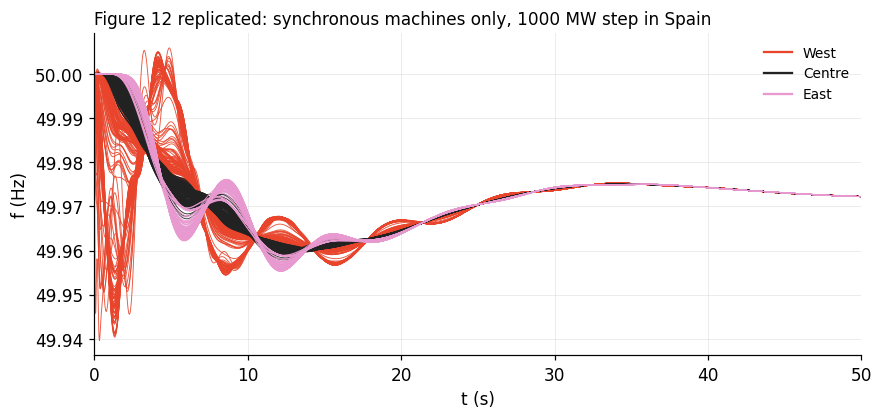

nadir 49.9396 Hz, mean frequency 50 s after the step 49.9722 Hz, E_osc 0.346
West minus East: inter-area mode at 0.142 Hz, damping ratio 12.9 %  (paper: about 0.13 Hz)


In [4]:
STEP = ['1.000 CHGPRM INJ DIST2178 P0 +1000 MW 0']      # P only, like the upstream conductance

case, d = make_case('fig12_sm', 'wamces_dyn_sm.dat', STEP, ['SYNC *'])
wall = run(case)
t12, F12 = read_freqs(d, 'machines')
print(f'machines only, 50 s after the step: {wall:.0f} s of wall time')

fig, ax = plt.subplots()
plot_areas(ax, t12 - 1.0, F12, M_AREA, 'Figure 12 replicated: synchronous machines only, 1000 MW step in Spain')
ax.set_xlim(0, 50)
plt.show()

A12 = area_means(F12, M_AREA)
f_we, z_we = fit_mode(t12, A12['West'] - A12['East'], 1.5, 40.0)
E12 = e_osc(t12, F12)
print(f'nadir {F12.min():.4f} Hz, mean frequency 50 s after the step {F12[-1].mean():.4f} Hz, E_osc {E12:.3f}')
print(f'West minus East: inter-area mode at {f_we:.3f} Hz, damping ratio {z_we:.1f} %  (paper: about 0.13 Hz)')

The simulated response reproduces the pattern of Fig. 12 in [1]. The Western machines, electrically closest to the disturbance, exhibit the deepest initial dip and the largest oscillation amplitude, the Eastern machines respond in antiphase, and the swing decays within approximately 20 s before all areas settle together below 50 Hz under primary frequency control. The frequency of the West-East oscillation obtained from (2) and (3) lies within 0.02 Hz of the value in [1]. The corresponding damping ratio characterises a signal that also carries the other inter-area modes; the eigenvalues computed in Section 4 therefore provide the more reliable estimate of damping.

## 4. Modal Analysis

Tables 2 to 4 of [1] report the frequency and damping ratio of the East-Centre-West, East-West and North-South inter-area modes for synchronous generation only, for IBRs without WADC and for IBRs with WADC. The dense small-signal analysis of RAMSES is limited to 5000 state variables, whereas the linearised model comprises more than 11000; the modes are therefore computed with a sparse shift-invert method applied to the unreduced descriptor system, an approach established for large-scale power system models [4], [5].

The linearisation of the differential-algebraic model around the operating point yields the descriptor system

$$E\, \dot{x} = A\, x \tag{4}$$

where $x$ collects the state and algebraic variables, $A$ is the Jacobian matrix, in which every differential equation is already divided by its time constant, and $E$ is a binary matrix holding one unit entry per differential equation, in the column of the state that equation differentiates, and zero rows for the algebraic equations. The modes of (4) are the finite eigenvalues $\lambda$ of the matrix pencil

$$A\, v = \lambda\, E\, v \tag{5}$$

with $v$ the corresponding right eigenvector. For a complex shift $\sigma$, the eigenvalues of (5) closest to $\sigma$ are obtained from the largest eigenvalues $\mu$ of the shift-inverted operator,

$$(A - \sigma E)^{-1} E\, v = \mu\, v, \qquad \lambda = \sigma + \frac{1}{\mu} \tag{6}$$

which is applied through one sparse LU factorisation of $A - \sigma E$ per shift and is never formed explicitly. The shifts $\sigma$ in (6) have a real part of $-0.05\ \mathrm{s}^{-1}$ and imaginary parts spaced by $2\pi \cdot 0.05$ rad/s from 0.1 Hz to 0.5 Hz, and the ten eigenvalues nearest to each shift are retained.

Two modelling choices follow from the linearisation that the engine provides. The synchronous reference frame (`$OMEGA_REF SYN`) replaces the centre-of-inertia reference, because the assembled Jacobian omits the centre-of-inertia coupling equations. The PMUs are removed from the IBR configuration, since they act as observers and influence the dynamics only through the WADC, which is not part of the model. Each mode is classified from its speed mode shape through the mean in-phase participation of the machines in each area and in a northern (DE, NL, BE, DK, PL, CZ, LU) and a southern (IT, GR, AL, MK, ME) group of countries.

In [5]:
def jacobian(dyn, tag):
    """Sparse DAE Jacobian (E x' = A x) at the initial operating point, and the
    row of every machine's speed state."""
    syn = os.path.join(RUNS, 'settings_syn.dat')
    with open(syn, 'w') as fh:
        fh.write(re.sub(r'\$OMEGA_REF\s+COI', '$OMEGA_REF SYN', open('wamces_settings.dat').read()))
    case, d = make_case(tag, dyn, [], ['SYNC *'], tend=1.0, settings=syn)
    cwd = os.getcwd()
    os.chdir(d)                          # getJac writes its py_*.dat files here
    try:
        sim = stepss.sim()
        sim.execSim(case, 0.0)
        A, E = sim.getJac()
        finish(sim)
        del sim
        omega = {}
        for line in open('py_var.dat'):
            f = line.split()
            if len(f) >= 5 and f[2] == 'SYN' and f[4] == 'omega':
                omega[f[3]] = int(f[0]) - 1
    finally:
        os.chdir(cwd)
    return A.tocsc(), E.tocsc(), omega


def modes(A, E, omega, f_lo=0.1, f_hi=0.5):
    """Every mode between f_lo and f_hi, by shift-invert around a comb of targets,
    with its speed mode shape normalised to the largest machine."""
    idx = np.array([omega[n] for n in MACH])
    found = []
    for f_t in np.arange(f_lo, f_hi + 1e-9, 0.05):
        sigma = complex(-0.05, 2 * np.pi * f_t)
        lu = spl.splu((A - sigma * E).astype(complex).tocsc())
        op = spl.LinearOperator(A.shape, matvec=lambda x: lu.solve(E @ x), dtype=complex)
        mu, V = spl.eigs(op, k=10, which='LM', tol=1e-9)
        for m_, v in zip(mu, V.T):
            lam = sigma + 1 / m_
            if lam.imag <= 0 or not f_lo - 0.02 < lam.imag / 2 / np.pi < f_hi + 0.02:
                continue
            if any(abs(lam - x[0]) < 1e-4 for x in found):
                continue
            w = v[idx]
            found.append((lam, w / w[np.argmax(abs(w))]))
    return sorted(found, key=lambda x: x[0].imag)


NORTH = {'DE', 'NL', 'BE', 'DK', 'PL', 'CZ', 'LU'}
SOUTH = {'IT', 'GR', 'AL', 'MK', 'ME'}
M_CTRY = np.array([country(b) for b in MACH.values()])
M_NS = np.array(['N' if c in NORTH else 'S' if c in SOUTH else '-' for c in M_CTRY])


def shape(w):
    """Mean in-phase speed participation of each group of machines."""
    g = {a: w[M_AREA == a].real.mean() for a in AREAS}
    g.update(North=w[M_NS == 'N'].real.mean(), South=w[M_NS == 'S'].real.mean())
    return g


def classify(w):
    g = shape(w)
    if g['West'] * g['East'] < 0 and min(abs(g['West']), abs(g['East'])) > 0.3:
        return 'East-West'
    if g['West'] * g['East'] > 0 and g['Centre'] * g['East'] < 0 and abs(g['East']) > 0.3:
        return 'East-Centre-West'
    if g['North'] * g['South'] < 0 and abs(g['North']) > 0.15:
        return 'North-South'
    return ''


with open(os.path.join(RUNS, 'dyn_no_pmu.dat'), 'w') as fh:     # PMUs observe, they do not act
    fh.writelines(l for l in open('wamces_dyn.dat') if not l.startswith('INJEC PMU'))

modal = {}
for tag, dyn, label in [('ssa_sm', 'wamces_dyn_sm.dat', 'all synchronous generation, no IBRs'),
                        ('ssa_ibr', os.path.join(RUNS, 'dyn_no_pmu.dat'), 'integration of IBRs, no WADC')]:
    t0 = time.time()
    A, E, omega = jacobian(dyn, tag)
    modal[label] = modes(A, E, omega)
    print(f'{label}: {E.nnz} states, {len(modal[label])} modes near 0.1-0.5 Hz, {time.time() - t0:.0f} s')

all synchronous generation, no IBRs: 11126 states, 7 modes near 0.1-0.5 Hz, 164 s


integration of IBRs, no WADC: 17326 states, 8 modes near 0.1-0.5 Hz, 289 s


In [6]:
for label, ms in modal.items():
    print(f'\n{label}')
    print(f'  {"f [Hz]":>7}{"zeta [%]":>9}{"West":>7}{"Centre":>8}{"East":>7}{"North":>7}{"South":>7}  shape')
    for lam, w in ms:
        if lam.imag / 2 / np.pi > 0.5:
            continue
        g = shape(w)
        print(f'  {lam.imag / 2 / np.pi:7.3f}{-100 * lam.real / abs(lam):9.1f}'
              f'{g["West"]:+7.2f}{g["Centre"]:+8.2f}{g["East"]:+7.2f}{g["North"]:+7.2f}{g["South"]:+7.2f}  {classify(w)}')


all synchronous generation, no IBRs
   f [Hz] zeta [%]   West  Centre   East  North  South  shape
    0.145     17.1  +0.48   -0.12  -0.63  -0.11  -0.27  East-West
    0.190     17.5  +0.13   -0.15  +0.72  -0.16  +0.06  East-Centre-West
    0.235     17.2  +0.00   -0.00  +0.06  -0.12  +0.24  
    0.324     14.5  -0.12   +0.14  -0.15  +0.21  -0.10  North-South
    0.414     12.9  -0.17   -0.00  +0.03  +0.21  -0.08  North-South
    0.440     12.1  +0.04   -0.07  +0.01  +0.00  -0.12  
    0.495     11.1  -0.00   +0.01  +0.10  -0.02  -0.15  

integration of IBRs, no WADC
   f [Hz] zeta [%]   West  Centre   East  North  South  shape
    0.140     15.5  +0.47   -0.13  -0.60  -0.12  -0.27  East-West
    0.185     16.3  +0.11   -0.14  +0.73  -0.15  +0.07  East-Centre-West
    0.230     16.5  -0.00   -0.00  +0.05  -0.12  +0.24  
    0.317     14.2  -0.13   +0.14  -0.15  +0.21  -0.10  North-South
    0.404     12.7  -0.18   +0.00  +0.03  +0.21  -0.06  North-South
    0.432     11.9  +0.04   -0.

In [7]:
PAPER = {  # Tables 2 to 4 of the paper: (frequency Hz, damping %)
    'East-Centre-West': {'all synchronous generation, no IBRs': (0.23, 11), 'integration of IBRs, no WADC': (0.22, 14)},
    'East-West':        {'all synchronous generation, no IBRs': (0.13, 11), 'integration of IBRs, no WADC': (0.13, 20)},
    'North-South':      {'all synchronous generation, no IBRs': (0.39, 10), 'integration of IBRs, no WADC': (0.38, 11)},
}
table = {}
print(f'{"mode":18}{"configuration":38}{"paper":>14}{"RAMSES":>16}')
for kind, rows in PAPER.items():
    for label, (fp, zp) in rows.items():
        cand = [(lam, w) for lam, w in modal[label] if classify(w) == kind]
        lam = min(cand, key=lambda x: abs(x[0].imag / 2 / np.pi - fp))[0]
        f_r, z_r = lam.imag / 2 / np.pi, -100 * lam.real / abs(lam)
        table[(kind, label)] = (f_r, z_r)
        print(f'{kind:18}{label:38}{fp:6.2f} Hz {zp:3d} %{f_r:8.3f} Hz {z_r:4.1f} %')

mode              configuration                                  paper          RAMSES
East-Centre-West  all synchronous generation, no IBRs     0.23 Hz  11 %   0.190 Hz 17.5 %
East-Centre-West  integration of IBRs, no WADC            0.22 Hz  14 %   0.185 Hz 16.3 %
East-West         all synchronous generation, no IBRs     0.13 Hz  11 %   0.145 Hz 17.1 %
East-West         integration of IBRs, no WADC            0.13 Hz  20 %   0.140 Hz 15.5 %
North-South       all synchronous generation, no IBRs     0.39 Hz  10 %   0.414 Hz 12.9 %
North-South       integration of IBRs, no WADC            0.38 Hz  11 %   0.404 Hz 12.7 %


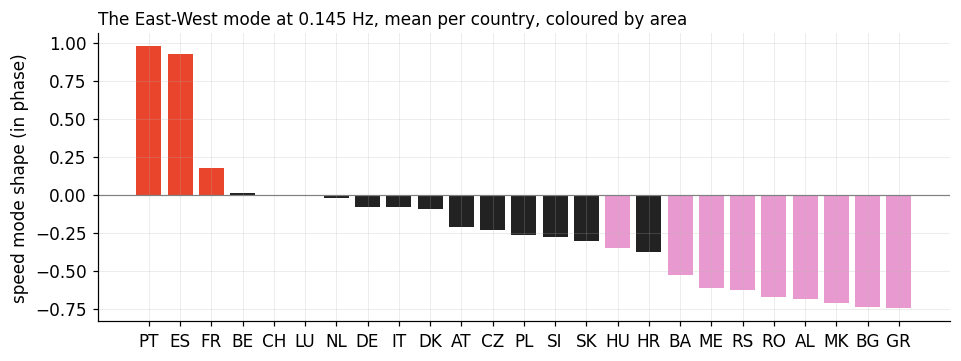

In [8]:
lam_ew, w_ew = min(((l, w) for l, w in modal['all synchronous generation, no IBRs'] if classify(w) == 'East-West'),
                   key=lambda x: abs(x[0].imag / 2 / np.pi - 0.13))
by_c = {}
for c, v in zip(M_CTRY, w_ew.real):
    by_c.setdefault(c, []).append(v)
order = sorted(by_c, key=lambda c: -np.mean(by_c[c]))
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(order, [np.mean(by_c[c]) for c in order],
       color=[AREA_COL['West' if c in WEST else 'East' if c in EAST else 'Centre'] for c in order])
ax.axhline(0, color='0.5', lw=0.8)
ax.set_ylabel('speed mode shape (in phase)')
ax.set_title(f'The East-West mode at {lam_ew.imag / 2 / np.pi:.3f} Hz, mean per country, coloured by area',
             loc='left', fontsize=11)
plt.show()

All three inter-area modes of [1] are identified in both configurations. The East-West and North-South modes lie within 0.03 Hz of the frequencies in [1], whereas the East-Centre-West mode is found approximately 0.04 Hz lower. Every mode exhibits a higher damping ratio than in [1], by 3 to 7 percentage points in the configuration without IBRs.

The effect of the IBRs differs qualitatively. In [1], their integration raises the damping of every mode, that of the East-West mode from 11% to 20%, whereas in the RAMSES model it lowers the damping slightly. This discrepancy is attributed to the converter models: in the conversion, the phase-locked loop of the grid-following converter is reduced to a single first-order response, and the voltage control gains of both converter types are not represented, while damping ratios depend directly on these loops. The configuration with WADC is not evaluated, because the controller of Section 8 is executed outside the model and therefore does not enter the Jacobian.

The East-West mode shape, aggregated per country, confirms the country assignment adopted in Section 2.1. Portugal and Spain oscillate against Greece, Bulgaria and the western Balkans, and the remaining countries are ordered approximately by longitude between these two groups. France lies close to the node of the mode and Croatia behaves as an Eastern rather than a Central country; neither assignment affects the West-East comparisons of the following sections.

## 5. Forced Oscillations

In [1], forced oscillations originate from a control malfunction in three neighbouring IBR plants on the Iberian peninsula, represented by an additional term in their active power reference,

$$P_{forced}(t) = K_{ampl}\, u(t) \sin(2\pi f_{osc} t) \tag{7}$$

where $K_{ampl} = 0.05$ pu is the amplitude on the converter rating, $f_{osc} = 0.6$ Hz the forcing frequency and $u(t)$ an activation envelope that ramps from zero to one, remains at one and ramps back to zero. Neither the three plants nor the timing of $u(t)$ is specified in [1].

The forcing sources are selected here as the three Spanish grid-forming converters with the smallest mutual distance measured in network branches. Although the grid-following converters also carry an active power reference, they were not selected, because their 10 MVA rating yields a forcing amplitude too small to reproduce Fig. 13 of [1]; the grid-forming set point `Po`, in contrast, is expressed in pu on the 200 MVA converter rating, the base of $K_{ampl}$. The envelope rises from 6 s to 10 s, holds until 16 s and decays to zero at 20 s, values read from that figure. The set point is updated every 20 ms and ramped linearly to the value that (7) takes at the next update instant.

forcing sources: GFM1803 at ES1803 (200 MVA), GFM1665 at ES1665 (200 MVA), GFM1804 at ES1804 (200 MVA)


full plant with forcing: 157 s of wall time


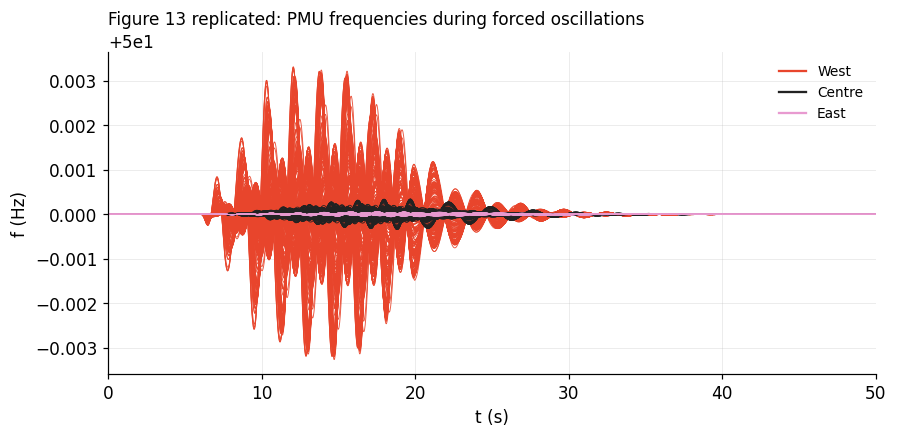

In [9]:
# three nearby Spanish grid-forming converters: the one whose two nearest neighbours are
# the fewest network hops away, by breadth-first search over lines and transformers
adj = {}
for line in open('wamces_lf.dat'):
    f = line.split()
    if f[:1] in (['LINE'], ['TRANSFO']):
        adj.setdefault(f[2], set()).add(f[3])
        adj.setdefault(f[3], set()).add(f[2])


def hops(src):
    dist, q = {src: 0}, deque([src])
    while q:
        u = q.popleft()
        for v in adj.get(u, ()):
            if v not in dist:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist


es_gfm = [g for g, (bus, _) in GFM.items() if country(bus) == 'ES']
best = None
for g in es_gfm:
    dist = hops(GFM[g][0])
    near = sorted((dist.get(GFM[h][0], 99), h) for h in es_gfm if h != g)[:2]
    score = sum(n for n, _ in near)
    if best is None or score < best[0]:
        best = (score, [g] + [h for _, h in near])
FORCED = best[1]
print('forcing sources:', ', '.join(f'{g} at {GFM[g][0]} ({GFM[g][1]:.0f} MVA)' for g in FORCED))

K_AMPL, F_OSC = 0.05, 0.6                              # pu on the converter rating, Hz (Section 5.1 of [1])
T_ON, T_FULL, T_DOWN, T_OFF = 6.0, 10.0, 16.0, 20.0     # activation envelope, read off Figure 13


def envelope(t):
    return float(np.interp(t, [T_ON, T_FULL, T_DOWN, T_OFF], [0, 1, 1, 0], left=0, right=0))


def forcing(sim, t, tc=0.02):
    """Ramp Po of the three converters to the value the forcing signal takes at t + tc."""
    dp = K_AMPL * (envelope(t + tc) * np.sin(2 * np.pi * F_OSC * (t + tc))
                   - envelope(t) * np.sin(2 * np.pi * F_OSC * t))
    if dp:
        for g in FORCED:
            sim.addDisturb(t + 1e-4, f'CHGPRM INJ {g} Po {dp:+.8f} {tc - 2e-4:.4f}')


PMU_OBS = [f'INJEC {n}' for n in PMU]
case, d = make_case('fig13_forced', 'wamces_dyn.dat', [], PMU_OBS)
wall = run(case, controller=forcing)
t13, P13 = read_freqs(d, 'pmu')
print(f'full plant with forcing: {wall:.0f} s of wall time')

fig, ax = plt.subplots()
plot_areas(ax, t13, P13, P_AREA, 'Figure 13 replicated: PMU frequencies during forced oscillations')
ax.set_xlim(0, 50)
plt.show()

In [10]:
# The PMUs of one area swing partly against each other, so the area mean hides the
# forcing; average the spectra of the individual PMUs instead, over the plateau.
# A run paused every 20 ms records extra samples at the pauses, so its time grid is not
# uniform; resample onto one before taking a spectrum.
keep = np.r_[True, np.diff(t13) > 1e-9]
tu = np.arange(T_FULL, T_DOWN, 0.02)
for a in AREAS:
    Y = np.column_stack([np.interp(tu, t13[keep], P13[keep, i]) for i in np.where(P_AREA == a)[0]])
    fr, pw = scipy.signal.periodogram(Y - Y.mean(axis=0), fs=1 / 0.02, nfft=8192, axis=0)
    band = (fr > 0.05) & (fr < 2.0)
    spec = pw[band].mean(axis=1)
    print(f'{a:6s}: dominant frequency {fr[band][np.argmax(spec)]:.3f} Hz, '
          f'median PMU swing {1e3 * np.median(np.ptp(Y, axis=0)):5.2f} mHz, largest {1e3 * np.ptp(Y, axis=0).max():5.2f} mHz peak to peak')

West  : dominant frequency 0.586 Hz, median PMU swing  1.17 mHz, largest  6.52 mHz peak to peak
Centre: dominant frequency 0.580 Hz, median PMU swing  0.19 mHz, largest  0.57 mHz peak to peak
East  : dominant frequency 0.586 Hz, median PMU swing  0.04 mHz, largest  0.10 mHz peak to peak


The PMU measurements reproduce the behaviour reported in [1]. The forced oscillation is concentrated in the West, where individual PMUs record swings of several millihertz, while the oscillation observed in the Centre and the East is smaller by more than an order of magnitude. The amplitude remains below that of Fig. 13 in [1], which is consistent with forcing sources selected rather than reported. The dominant frequency, obtained from the spectra of the individual PMUs averaged within each area, coincides with $f_{osc}$ in all three areas. The spectra are averaged per PMU because Western PMUs partly oscillate against each other, and these counter-phase components correspond to the intra-area oscillations that [1] identifies within the Western part of the system.

## 6. System Split

The system split of [1] disconnects the Iberian peninsula from the rest of the Continental European system by opening all interconnecting lines. The four lines concerned, all between France and Spain, are identified from the network data and opened simultaneously one second into the simulation. Iberia imports power over these lines before the event, approximately 2.5 GW according to [1]; the separation therefore leaves Iberia with a generation deficit and the remaining system with a surplus.

full plant, system split: 47 s of wall time
  L1035_1166_1 from FR1035:    1593 MW towards Spain
  L1449_1557_1 from FR1449:    1366 MW towards Spain
  L1558_1679_1 from FR1558:     246 MW towards Spain
  L1568_1687_1 from FR1568:     386 MW towards Spain
  total transfer before the split: 3591 MW  (paper: about 2.5 GW)


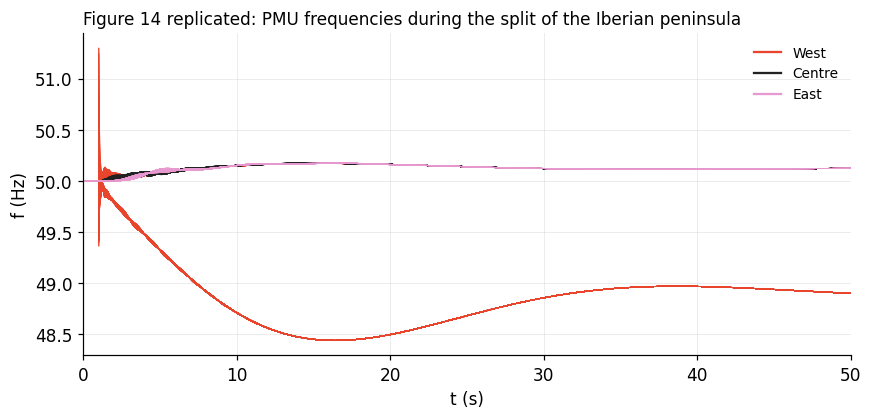

Iberian peninsula: nadir 48.437 Hz at t = 16.4 s, 48.892 Hz at t = 50 s
rest of the system (mean): peak 50.172 Hz at t = 15.4 s, 50.123 Hz at t = 50 s


In [11]:
TIES = []
for line in open('wamces_lf.dat'):
    f = line.split()
    if f[:1] == ['LINE'] and (country(f[2]) in ('ES', 'PT')) != (country(f[3]) in ('ES', 'PT')):
        TIES.append((f[1], f[2]))
tie_flow = {}


def read_ties(sim):
    for name, bus in TIES:
        tie_flow[name] = sim.getBranchPow([name])


case, d = make_case('fig14_split', 'wamces_dyn.dat',
                    [f'1.000 BREAKER BRANCH {name} 0 0' for name, _ in TIES], PMU_OBS)
wall = run(case, at_start=read_ties)
t14, P14 = read_freqs(d, 'pmu')
print(f'full plant, system split: {wall:.0f} s of wall time')
total = 0.0
for name, bus in TIES:
    p = 100.0 * tie_flow[name][0][0]            # pu on 100 MVA at the French end, positive into the line
    total += p
    print(f'  {name} from {bus}: {p:7.0f} MW towards Spain')
print(f'  total transfer before the split: {total:.0f} MW  (paper: about 2.5 GW)')

IBERIA = np.array([country(b) in ('ES', 'PT') for b in PMU.values()])
fig, ax = plt.subplots()
plot_areas(ax, t14, P14, P_AREA, 'Figure 14 replicated: PMU frequencies during the split of the Iberian peninsula')
ax.set_xlim(0, 50)
plt.show()
print(f'Iberian peninsula: nadir {P14[:, IBERIA].min():.3f} Hz at t = {t14[P14[:, IBERIA].mean(axis=1).argmin()]:.1f} s, '
      f'{P14[-1, IBERIA].mean():.3f} Hz at t = 50 s')
rest = P14[:, ~IBERIA].mean(axis=1)
print(f'rest of the system (mean): peak {rest.max():.3f} Hz at t = {t14[rest.argmax()]:.1f} s, {rest[-1]:.3f} Hz at t = 50 s')

The response matches Fig. 14 of [1]. The Iberian frequency reaches its nadir approximately 15 s after the separation and recovers only partially under primary control, whereas the frequency of the remaining system rises by less than 0.2 Hz and settles slightly above 50 Hz. The spikes at the instant of separation reflect the response of the PMU phase-locked loops to the step change of the voltage angle and appear in [1] as well. The transfer before the event exceeds the value quoted in [1] by approximately 1.1 GW, although the operating point is the published power flow solution, and [1] does not state how its value was obtained. Neither model includes underfrequency load shedding, which in practice would act well before the nadir is reached.

## 7. Power Imbalance with Inverter-Based Resources

The imbalance of Section 3 is repeated with all 800 converters in service and without WADC. This configuration coincides with the base case of the published MATLAB/Simulink script [2], which permits a direct comparison with a run of that implementation; its area-mean frequencies and its oscillation energy are stored in `reference/matlab_fig15_area_means.csv`.

full plant, 1000 MW step: 42 s of wall time


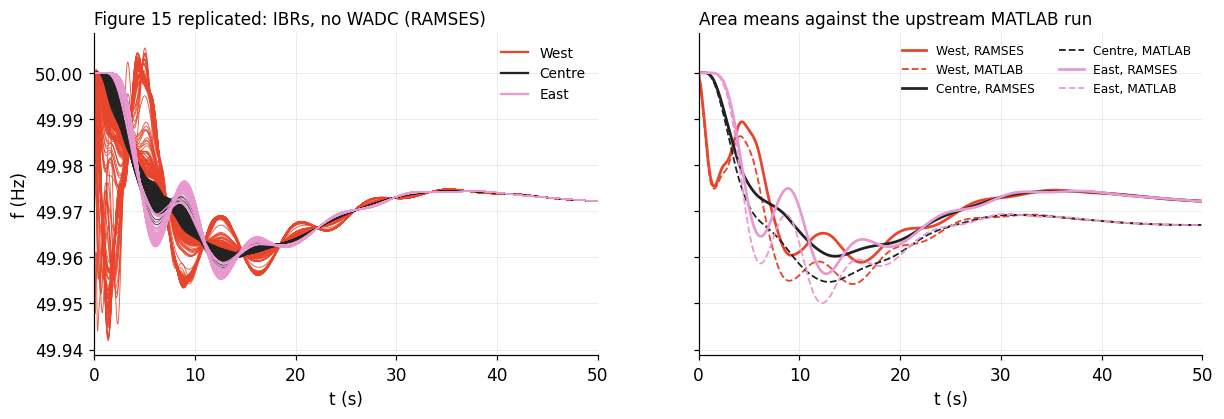

E_osc: RAMSES 0.361, upstream MATLAB 0.358, paper 0.36
E_osc with machines only (Section 3) 0.346: the converters raise it by 4 %
West minus East: RAMSES 0.137 Hz at 11.9 %, MATLAB 0.143 Hz at 12.3 %


In [12]:
case, d = make_case('fig15_ibr', 'wamces_dyn.dat', STEP, ['SYNC *'])
wall = run(case)
t15, F15 = read_freqs(d, 'machines')
print(f'full plant, 1000 MW step: {wall:.0f} s of wall time')

REF_FILE = 'reference/matlab_fig15_area_means.csv'
ref = np.loadtxt(REF_FILE, delimiter=',', comments='#', skiprows=5)
E_REF = float(re.search(r'E_osc .*: ([\d.]+)', open(REF_FILE).read()).group(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
plot_areas(axes[0], t15 - 1.0, F15, M_AREA, 'Figure 15 replicated: IBRs, no WADC (RAMSES)')
A15 = area_means(F15, M_AREA)
for i, a in enumerate(AREAS):
    axes[1].plot(t15 - 1.0, A15[a], color=AREA_COL[a], lw=1.8, label=f'{a}, RAMSES')
    axes[1].plot(ref[:, 0], ref[:, i + 1], color=AREA_COL[a], lw=1.2, ls='--', label=f'{a}, MATLAB')
axes[1].set_title('Area means against the upstream MATLAB run', loc='left', fontsize=11)
axes[1].set_xlabel('t (s)')
axes[1].legend(fontsize=8, ncol=2)
for ax in axes:
    ax.set_xlim(0, 50)
plt.show()

E15 = e_osc(t15, F15)
f15, z15 = fit_mode(t15, A15['West'] - A15['East'], 1.5, 40.0)
fr_, zr_ = fit_mode(ref[:, 0] + 1.0, ref[:, 1] - ref[:, 3], 1.5, 40.0)
print(f'E_osc: RAMSES {E15:.3f}, upstream MATLAB {E_REF:.3f}, paper 0.36')
print(f'E_osc with machines only (Section 3) {E12:.3f}: the converters raise it by {100 * (E15 / E12 - 1):.0f} %')
print(f'West minus East: RAMSES {f15:.3f} Hz at {z15:.1f} %, MATLAB {fr_:.3f} Hz at {zr_:.1f} %')

The oscillation energy (1) agrees with the MATLAB run and with the value in [1] to within 0.01, and the West-East oscillation exhibits nearly identical frequency and damping in both implementations. The area-mean frequencies follow the MATLAB trajectories closely during the first swings and differ by a few millihertz in the settling frequency. Two differences between the implementations can account for this offset: the RAMSES model has a single slack bus where the MATLAB model has five, and its converter models are simplified as discussed in Section 4.

With respect to the case of Section 3, the converters increase the oscillation energy by approximately 4%. This is the direction reported in [1] when its Figs. 12 and 15 are compared, and it is consistent with the slightly lower modal damping found in Section 4 when the converters are connected.

## 8. Wide-Area Damping Control

The WADC of [1] employs the average frequency of all PMUs as a global feedback signal,

$$\omega_{avg}(t) = \frac{1}{N_{PMU}} \sum_{i=1}^{N_{PMU}} \omega_{PMU,i}(t - T_d) \tag{8}$$

where $N_{PMU} = 1573$ is the number of PMUs, $\omega_{PMU,i}$ the frequency measured by PMU $i$ in pu, and $T_d = 0.1$ s the latency of the link from each PMU to the central unit. The central unit returns $\omega_{avg}$ to every grid-forming converter, which adds to its active power set point

$$\Delta P_w(t) = K_w \left( \omega_{avg}(t - T_d) - \omega(t) \right) \tag{9}$$

where $K_w$ is the control gain, $\omega$ the frequency of the converter in pu and $\Delta P_w$ the additional active power in pu on the rating of each converter. As in [1], each latency is represented by the second-order Padé approximant

$$G(s) = \frac{1 - s T_d / 2 + s^2 T_d^2 / 12}{1 + s T_d / 2 + s^2 T_d^2 / 12} \tag{10}$$

where $s$ denotes the Laplace variable.

The controller is implemented in Python with a sample time of 20 ms, equal to the integration step. At every sample, the simulation is paused and the 1573 PMU frequencies and the 300 converter speeds are read; the average passes through two cascaded instances of (10), discretised with a zero-order hold, and each converter set point is ramped to the value of (9) over the following sample. Because all latencies are equal and (8) is linear, delaying the average is equivalent to averaging the delayed measurements. The data of [1] set $K_w = 0$, and the gain employed for Fig. 16 of [1] is not stated; $K_w$ is therefore varied, and the case whose reduction of the oscillation energy is closest to that of [1] is presented.

In [13]:
TD = 0.1                                  # s, latency of each link (Td in data_gfm and data_pmu)
TC = 0.02                                 # s, controller sample time, the solver's step


def pade2(td, dt):
    """Second-order Pade approximant of a delay td, discretised exactly (zero-order hold)."""
    num = [td ** 2 / 12, -td / 2, 1]
    den = [td ** 2 / 12, td / 2, 1]
    A, B, C, D = scipy.signal.tf2ss(num, den)
    Ad, Bd, Cd, Dd, _ = scipy.signal.cont2discrete((A, B, C, D), dt)
    return Ad, Bd, Cd, Dd


class WADC:
    """Paper eqs. (64) and (65): the average of all PMU frequencies, delayed on its way to
    the central unit and again on its way back, against each converter's own frequency."""

    def __init__(self, kw):
        self.kw = kw
        self.link = pade2(TD, TC)
        self.x = [np.zeros((2, 1)), np.zeros((2, 1))]     # uplink, downlink
        self.started = False
        self.pmus = list(PMU)
        self.gfms = list(GFM)
        self.applied = np.zeros(len(self.gfms))

    def delay(self, i, u):
        Ad, Bd, Cd, Dd = self.link
        y = (Cd @ self.x[i] + Dd * u).item()
        self.x[i] = Ad @ self.x[i] + Bd * u
        return y

    def __call__(self, sim, t):
        f = np.array(sim.getObs(['INJ'] * len(self.pmus), self.pmus, ['f'] * len(self.pmus)))
        w = np.array(sim.getObs(['INJ'] * len(self.gfms), self.gfms, ['omegam'] * len(self.gfms)))
        if not self.started:                               # links start in steady state
            Ad, Bd, _, _ = self.link
            for i in range(2):
                self.x[i] = np.linalg.solve(np.eye(2) - Ad, Bd) * (f.mean() - 1.0)
            self.started = True
        w_avg = 1.0 + self.delay(1, self.delay(0, f.mean() - 1.0))
        target = self.kw * (w_avg - w)                     # pu on each converter's rating
        for g, dp in zip(self.gfms, target - self.applied):
            if abs(dp) > 1e-9:
                sim.addDisturb(t + 1e-4, f'CHGPRM INJ {g} Po {dp:+.8f} {TC - 2e-4:.4f}')
        self.applied = target

In [14]:
KW = (10.0, 40.0, 80.0)
wadc = {}
for kw in KW:
    case, d = make_case(f'fig16_wadc_kw{kw:g}', 'wamces_dyn.dat', STEP, ['SYNC *'])
    wall = run(case, controller=WADC(kw), tc=TC)
    t, F = read_freqs(d, 'machines')
    wadc[kw] = (t, F)
    print(f'Kw = {kw:4g}: {wall:4.0f} s of wall time, E_osc {e_osc(t, F):.3f} '
          f'({100 * (1 - e_osc(t, F) / E15):.0f} % below no WADC), nadir {F.min():.4f} Hz')

Kw =   10:  402 s of wall time, E_osc 0.248 (31 % below no WADC), nadir 49.9453 Hz


Kw =   40:  417 s of wall time, E_osc 0.125 (65 % below no WADC), nadir 49.9462 Hz


Kw =   80:  415 s of wall time, E_osc 0.076 (79 % below no WADC), nadir 49.9470 Hz


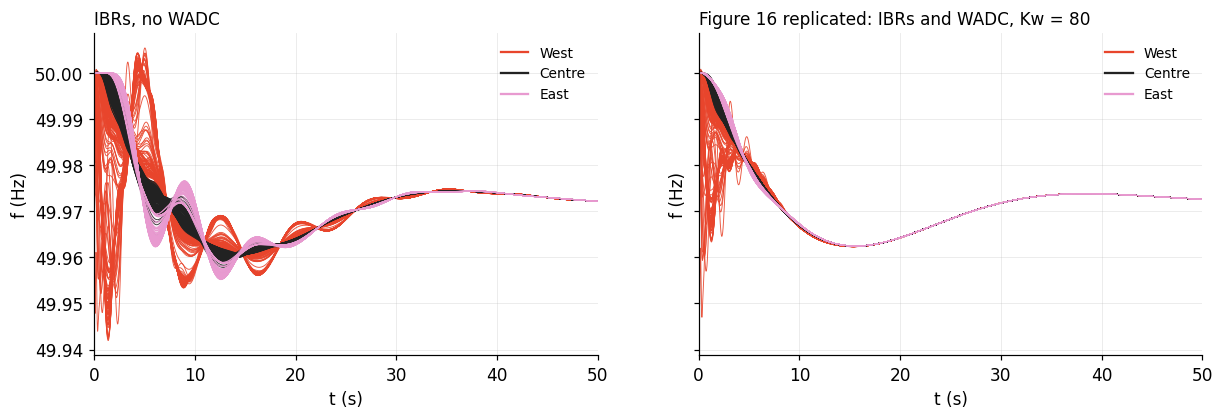

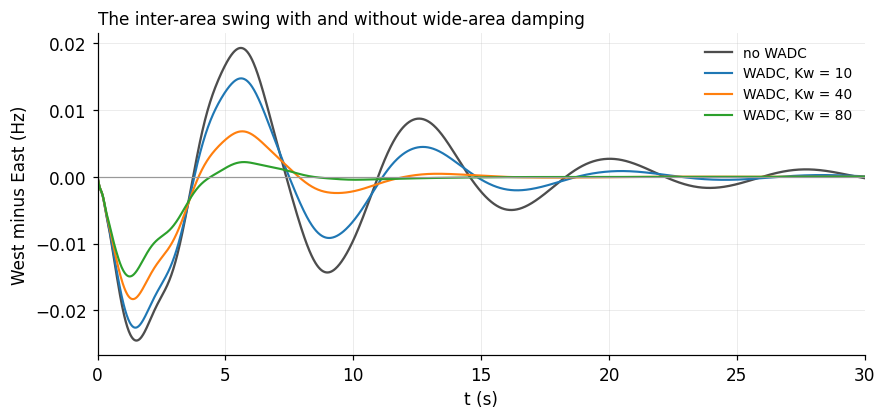

E_osc: no WADC 0.361, WADC with Kw = 80 0.076, a reduction of 79 %
paper: 0.36 and 0.06, a reduction of about 80 %


In [15]:
KW_SHOW = 80.0
t16, F16 = wadc[KW_SHOW]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
plot_areas(axes[0], t15 - 1.0, F15, M_AREA, 'IBRs, no WADC')
plot_areas(axes[1], t16 - 1.0, F16, M_AREA, f'Figure 16 replicated: IBRs and WADC, Kw = {KW_SHOW:g}')
for ax in axes:
    ax.set_xlim(0, 50)
plt.show()

fig, ax = plt.subplots()
ax.plot(t15 - 1.0, A15['West'] - A15['East'], color='0.3', label='no WADC')
for kw in KW:
    t, F = wadc[kw]
    A = area_means(F, M_AREA)
    ax.plot(t - 1.0, A['West'] - A['East'], lw=1.4, label=f'WADC, Kw = {kw:g}')
ax.axhline(0, color='0.6', lw=0.8)
ax.set_xlim(0, 30)
ax.set_xlabel('t (s)')
ax.set_ylabel('West minus East (Hz)')
ax.set_title('The inter-area swing with and without wide-area damping', loc='left', fontsize=11)
ax.legend(fontsize=9)
plt.show()

E16 = e_osc(t16, F16)
print(f'E_osc: no WADC {E15:.3f}, WADC with Kw = {KW_SHOW:g} {E16:.3f}, a reduction of {100 * (1 - E16 / E15):.0f} %')
print('paper: 0.36 and 0.06, a reduction of about 80 %')

The WADC damps the West-East oscillation progressively more as $K_w$ increases, in agreement with Fig. 16 of [1]. At the largest gain of the range, the decrease of $E_{osc}$ relative to the case without control matches the reduction of about 80% in [1] within one percentage point, and the areas oscillate coherently after approximately one period of the mode. The first frequency dip, to which the controller can respond only after the round-trip latency of 0.2 s, is reduced considerably less than the subsequent swings.

The frequency nadir remains practically unchanged for all gains, since (9) acts on the deviation of each converter from the system average frequency and leaves the overall power balance to primary control. Since [1] leaves $K_w$ unspecified, this agreement concerns the behaviour of the control and a reduction attained at one gain rather than the replication of a published setting; the sensitivity of such schemes to the communication latency [6] also means that the gain found here is specific to the delay model (10).

## 9. Conclusions

The replicated quantities are compared below with the values reported in [1].

In [16]:
def cell(key):
    return '{:.3f} Hz, {:.1f} %'.format(*table[key])


SM, IBR = 'all synchronous generation, no IBRs', 'integration of IBRs, no WADC'
rows = [
    ('Fig. 12, East-West swing, machines only', 'about 0.13 Hz', f'{f_we:.3f} Hz, {z_we:.1f} %'),
    ('Table 3, East-West, no IBRs', '0.13 Hz, 11 %', cell(('East-West', SM))),
    ('Table 3, East-West, IBRs no WADC', '0.13 Hz, 20 %', cell(('East-West', IBR))),
    ('Table 2, East-Centre-West, no IBRs', '0.23 Hz, 11 %', cell(('East-Centre-West', SM))),
    ('Table 2, East-Centre-West, IBRs no WADC', '0.22 Hz, 14 %', cell(('East-Centre-West', IBR))),
    ('Table 4, North-South, no IBRs', '0.39 Hz, 10 %', cell(('North-South', SM))),
    ('Table 4, North-South, IBRs no WADC', '0.38 Hz, 11 %', cell(('North-South', IBR))),
    ('Fig. 14, Iberian nadir after the split', 'about 48.5 Hz', f'{P14[:, IBERIA].min():.2f} Hz'),
    ('Fig. 15, E_osc, IBRs no WADC', '0.36', f'{E15:.2f} (MATLAB {E_REF:.2f})'),
    (f'Fig. 16, E_osc with WADC, Kw = {KW_SHOW:g}', '0.06, about -80 %', f'{E16:.2f}, {-100 * (1 - E16 / E15):.0f} %'),
]
w0 = max(len(r[0]) for r in rows) + 2
print(f'{"result":{w0}}{"paper":20}RAMSES')
for r in rows:
    print(f'{r[0]:{w0}}{r[1]:20}{r[2]}')

result                                   paper               RAMSES
Fig. 12, East-West swing, machines only  about 0.13 Hz       0.142 Hz, 12.9 %
Table 3, East-West, no IBRs              0.13 Hz, 11 %       0.145 Hz, 17.1 %
Table 3, East-West, IBRs no WADC         0.13 Hz, 20 %       0.140 Hz, 15.5 %
Table 2, East-Centre-West, no IBRs       0.23 Hz, 11 %       0.190 Hz, 17.5 %
Table 2, East-Centre-West, IBRs no WADC  0.22 Hz, 14 %       0.185 Hz, 16.3 %
Table 4, North-South, no IBRs            0.39 Hz, 10 %       0.414 Hz, 12.9 %
Table 4, North-South, IBRs no WADC       0.38 Hz, 11 %       0.404 Hz, 12.7 %
Fig. 14, Iberian nadir after the split   about 48.5 Hz       48.44 Hz
Fig. 15, E_osc, IBRs no WADC             0.36                0.36 (MATLAB 0.36)
Fig. 16, E_osc with WADC, Kw = 80        0.06, about -80 %   0.08, -79 %


This notebook replicated the simulation studies of [1] on the RAMSES conversion of the WAMCES model, driving every case from Python and realising the WADC outside the dynamic model. The time-domain results agree with [1] and with the MATLAB/Simulink model of its authors: the West-East inter-area oscillation, the frequency trajectories of the system split and the oscillation energy with and without WADC are reproduced closely.

The replication departs from [1] in three respects. First, the modal analysis identifies the inter-area modes at frequencies close to those of [1] but with higher damping, and the integration of IBRs lowers this damping instead of raising it, which points to the simplified converter models of the conversion. Second, the forcing sources of Section 5 and the WADC gain are unpublished, so these two studies reproduce the published behaviour rather than a published configuration. Third, no modal result can be given for the controlled system, because the controller is external to the model.

Future work concerns the converter models, whose phase-locked loop and voltage control dynamics must be represented as in [1] before the damping ratios of Tables 2 to 4 can be compared quantitatively. Integrating the WADC in the dynamic model would enable its modal assessment, and adjusting the Iberian import to the 2.5 GW stated in [1] would align the system split with the published operating conditions.

### References

[1] R. Musca, M. G. Ippolito and E. Riva Sanseverino, "Dynamic model of the European power system for wide-area monitoring and control applications," *Electricity*, vol. 7, no. 2, art. 28, 2026, doi: [10.3390/electricity7020028](https://doi.org/10.3390/electricity7020028).

[2] R. Musca, M. G. Ippolito and E. Riva Sanseverino, WAMCES model data and MATLAB/Simulink implementation, Zenodo, record 18721887. [https://zenodo.org/records/18721887](https://zenodo.org/records/18721887)

[3] P. Aristidou, S. Lebeau, L. Loud and T. Van Cutsem, "Prospects of a new dynamic simulation software for real-time applications on the Hydro-Quebec system," *CIGRE Science & Engineering*, 2016.

[4] J. Rommes, N. Martins and F. D. Freitas, "Computing rightmost eigenvalues for small-signal stability assessment of large-scale power systems," *IEEE Transactions on Power Systems*, vol. 25, no. 2, pp. 929-938, 2010, doi: [10.1109/TPWRS.2009.2036822](https://doi.org/10.1109/tpwrs.2009.2036822).

[5] P. Aristidou and G. Hug, "Accelerating the computation of critical eigenvalues with parallel computing techniques," in *Proc. Power Systems Computation Conference (PSCC)*, 2016, pp. 1-8, doi: [10.1109/PSCC.2016.7540976](https://doi.org/10.1109/pscc.2016.7540976).

[6] S. Alghamdi, U. Markovic, O. Stanojev, J. Schiffer, G. Hug and P. Aristidou, "Wide-area oscillation damping in low-inertia grids under time-varying communication delays," *Electric Power Systems Research*, vol. 189, art. 106629, 2020, doi: [10.1016/j.epsr.2020.106629](https://doi.org/10.1016/j.epsr.2020.106629).

[7] stepss Python interface documentation. [https://stepss.sps-lab.org/python/](https://stepss.sps-lab.org/python/)